# Steps 4-5: NLP Preprocessing & Feature Extraction

Text cleaning, sentiment analysis (VADER/TextBlob), TF-IDF, and occupation clustering.

In [1]:
import sys
sys.path.insert(0, '/home/jovyan/work/src')

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from nlp_pipeline import (clean_text, add_sentiment_features, get_vader_sentiment,
                          get_textblob_sentiment, build_tfidf_features,
                          cluster_occupations, create_missing_text_flag)

plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams['figure.dpi'] = 120

## 4.1 Load Data

For development, load directly from CSV. After Weiyu completes notebooks 01-03, switch to reading from `features_baseline.parquet`.

In [2]:
# Development: load from CSV
df_pd = pd.read_csv('/home/jovyan/work/data/raw/accepted_2007_to_2018Q4.csv',
                    usecols=['desc', 'title', 'emp_title', 'loan_status'],
                    dtype=str)

print(f'Total rows: {len(df_pd)}')
print(f'Rows with desc: {df_pd["desc"].notna().sum()}')

# Balanced sample: 5000 with desc + 5000 without
df_with_desc = df_pd[df_pd['desc'].notna()].sample(5000, random_state=42)
df_without_desc = df_pd[df_pd['desc'].isna()].sample(5000, random_state=42)
df_sample = pd.concat([df_with_desc, df_without_desc]).reset_index(drop=True)

print(f'Sample: {len(df_sample)} rows, with desc: {df_sample["desc"].notna().sum()}')

Total rows: 2260701
Rows with desc: 126065
Sample: 10000 rows, with desc: 5000


## 4.2 Missing Rate Overview

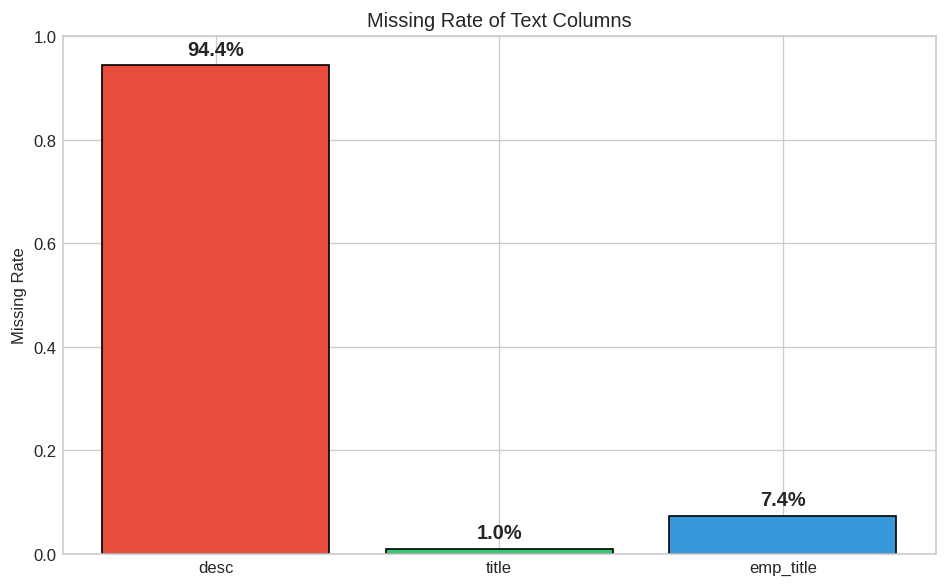

In [3]:
# Missing rate for each text column (on full data)
missing_rates = {
    'desc': df_pd['desc'].isna().mean(),
    'title': df_pd['title'].isna().mean(),
    'emp_title': df_pd['emp_title'].isna().mean(),
}

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['#e74c3c', '#2ecc71', '#3498db']
bars = ax.bar(missing_rates.keys(), missing_rates.values(), color=colors, edgecolor='black')
ax.set_ylabel('Missing Rate')
ax.set_title('Missing Rate of Text Columns')
ax.set_ylim(0, 1)

# Add percentage labels on bars
for bar, rate in zip(bars, missing_rates.values()):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
            f'{rate:.1%}', ha='center', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/text_missing_rates.png', dpi=150)
plt.show()

`desc` has a 94.4% missing rate — Lending Club removed this field after ~2012. `title` and `emp_title` are mostly complete. The high missing rate of `desc` is itself a useful feature (see below).

## 4.3 Text Cleaning Demo

Show before/after examples of text cleaning on `desc` field.

In [4]:
# Before/after cleaning examples
sample_texts = df_sample['desc'].dropna().head(5)
for i, text in enumerate(sample_texts, 1):
    print(f'--- Example {i} ---')
    print(f'BEFORE: {text[:150]}')
    print(f'AFTER : {clean_text(text)[:150]}')
    print()

--- Example 1 ---
BEFORE: I've ended up with a few loans from different places, and with relatively poor interest rates in retrospect. I would like to have one convenient payme
AFTER : ive ended loans different places relatively poor interest rates retrospect would like one convenient payment per month hopefully better interest rate 

--- Example 2 ---
BEFORE:   Borrower added on 10/29/13 > We have incurred a credit card loan over the past 10 yrs to Capital One.  The interest rate is high.  We want to pay th
AFTER : incurred credit card loan past yrs capital one interest rate high want pay loan interest capital one charges got debt helping parents brother

--- Example 3 ---
BEFORE:  385521 added on 10/17/09 > I plan to use this money to pay off credit cards and consolidate debt.  After this I will close my accounts.  I am a teach
AFTER : plan use money pay credit cards consolidate debt close accounts teacher stedy full time job always paid bills time full money also plan fixing car abl

Cleaning removes HTML tags (e.g. `<br>`), system templates ("Borrower added on..."), punctuation, and stopwords. The result retains only meaningful content words.

## 4.4 Missing Text Flags

In [5]:
df_sample = create_missing_text_flag(df_sample, 'desc')
df_sample = create_missing_text_flag(df_sample, 'title')

print(f'desc missing rate:  {df_sample["desc_missing"].mean():.2%}')
print(f'title missing rate: {df_sample["title_missing"].mean():.2%}')

desc missing rate:  50.00%
title missing rate: 0.46%


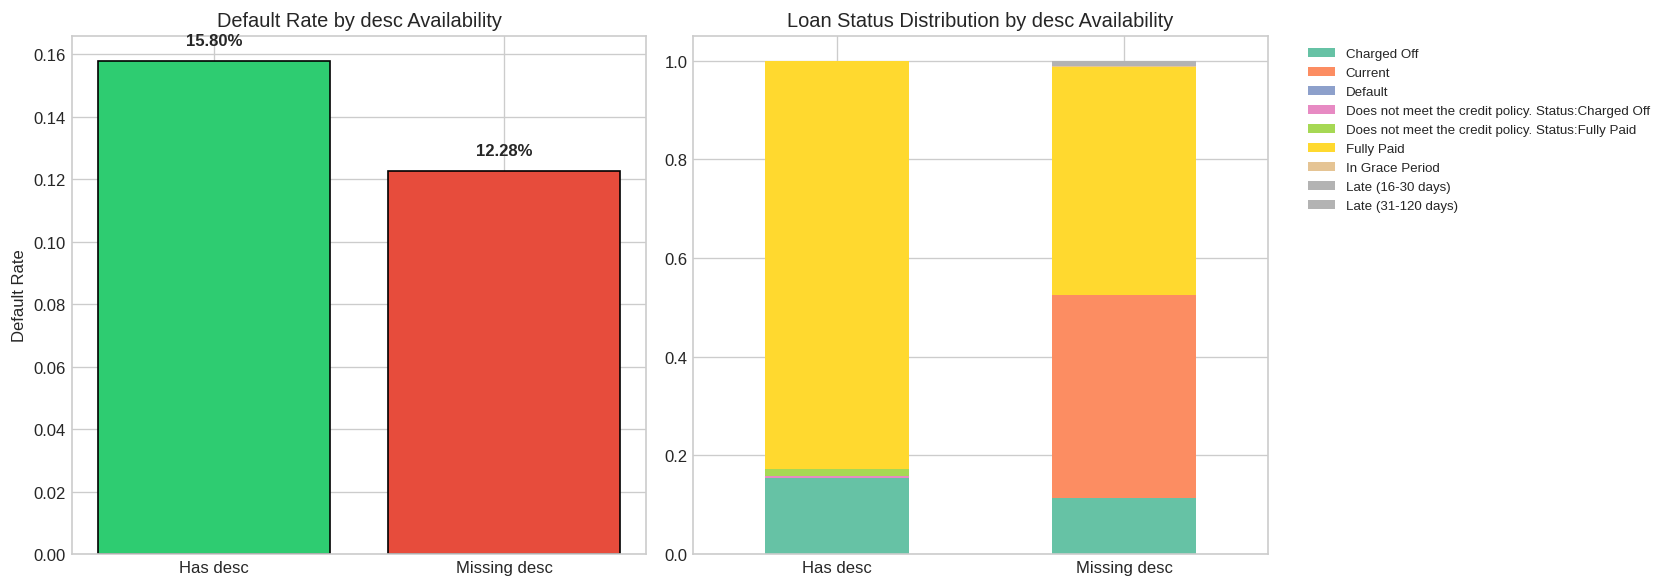

In [6]:
# Is desc_missing correlated with default?
from data_cleaning import DEFAULT_STATUSES
df_sample['default_flag'] = df_sample['loan_status'].isin(DEFAULT_STATUSES).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# desc_missing vs default rate
desc_default = df_sample.groupby('desc_missing')['default_flag'].mean()
axes[0].bar(['Has desc', 'Missing desc'], desc_default.values, color=['#2ecc71', '#e74c3c'], edgecolor='black')
axes[0].set_ylabel('Default Rate')
axes[0].set_title('Default Rate by desc Availability')
for i, v in enumerate(desc_default.values):
    axes[0].text(i, v + 0.005, f'{v:.2%}', ha='center', fontweight='bold')

# Loan status distribution by desc availability
status_counts = df_sample.groupby(['desc_missing', 'loan_status']).size().unstack(fill_value=0)
status_pct = status_counts.div(status_counts.sum(axis=1), axis=0)
status_pct.plot(kind='bar', stacked=True, ax=axes[1], colormap='Set2')
axes[1].set_title('Loan Status Distribution by desc Availability')
axes[1].set_xlabel('')
axes[1].set_xticklabels(['Has desc', 'Missing desc'], rotation=0)
axes[1].legend(bbox_to_anchor=(1.05, 1), loc='upper left', fontsize=8)

plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/desc_missing_vs_default.png', dpi=150, bbox_inches='tight')
plt.show()

Borrowers who wrote a description actually have a **higher** default rate (15.8% vs 12.3%). This is likely because `desc` was only available on older loans (2007–2012), which had higher default rates post-financial crisis. Loans without `desc` include many "Current" status loans that haven't matured yet. Either way, `desc_missing` is a discriminative feature.

## 4.5 Sentiment Analysis

In [7]:
df_sample = add_sentiment_features(df_sample, 'desc')
df_sample = add_sentiment_features(df_sample, 'title')

print('Sentiment features added:')
print(df_sample[['desc_vader', 'desc_textblob', 'title_vader', 'title_textblob']].describe())

Sentiment features added:
         desc_vader  desc_textblob   title_vader  title_textblob
count  10000.000000   10000.000000  10000.000000    10000.000000
mean       0.188242       0.048376     -0.050412        0.007815
std        0.357440       0.132952      0.319529        0.067470
min       -0.900100      -1.000000     -0.778300       -1.000000
25%        0.000000       0.000000     -0.361200        0.000000
50%        0.000000       0.000000      0.000000        0.000000
75%        0.401900       0.017500      0.381800        0.000000
max        0.998900       1.000000      0.910000        1.000000


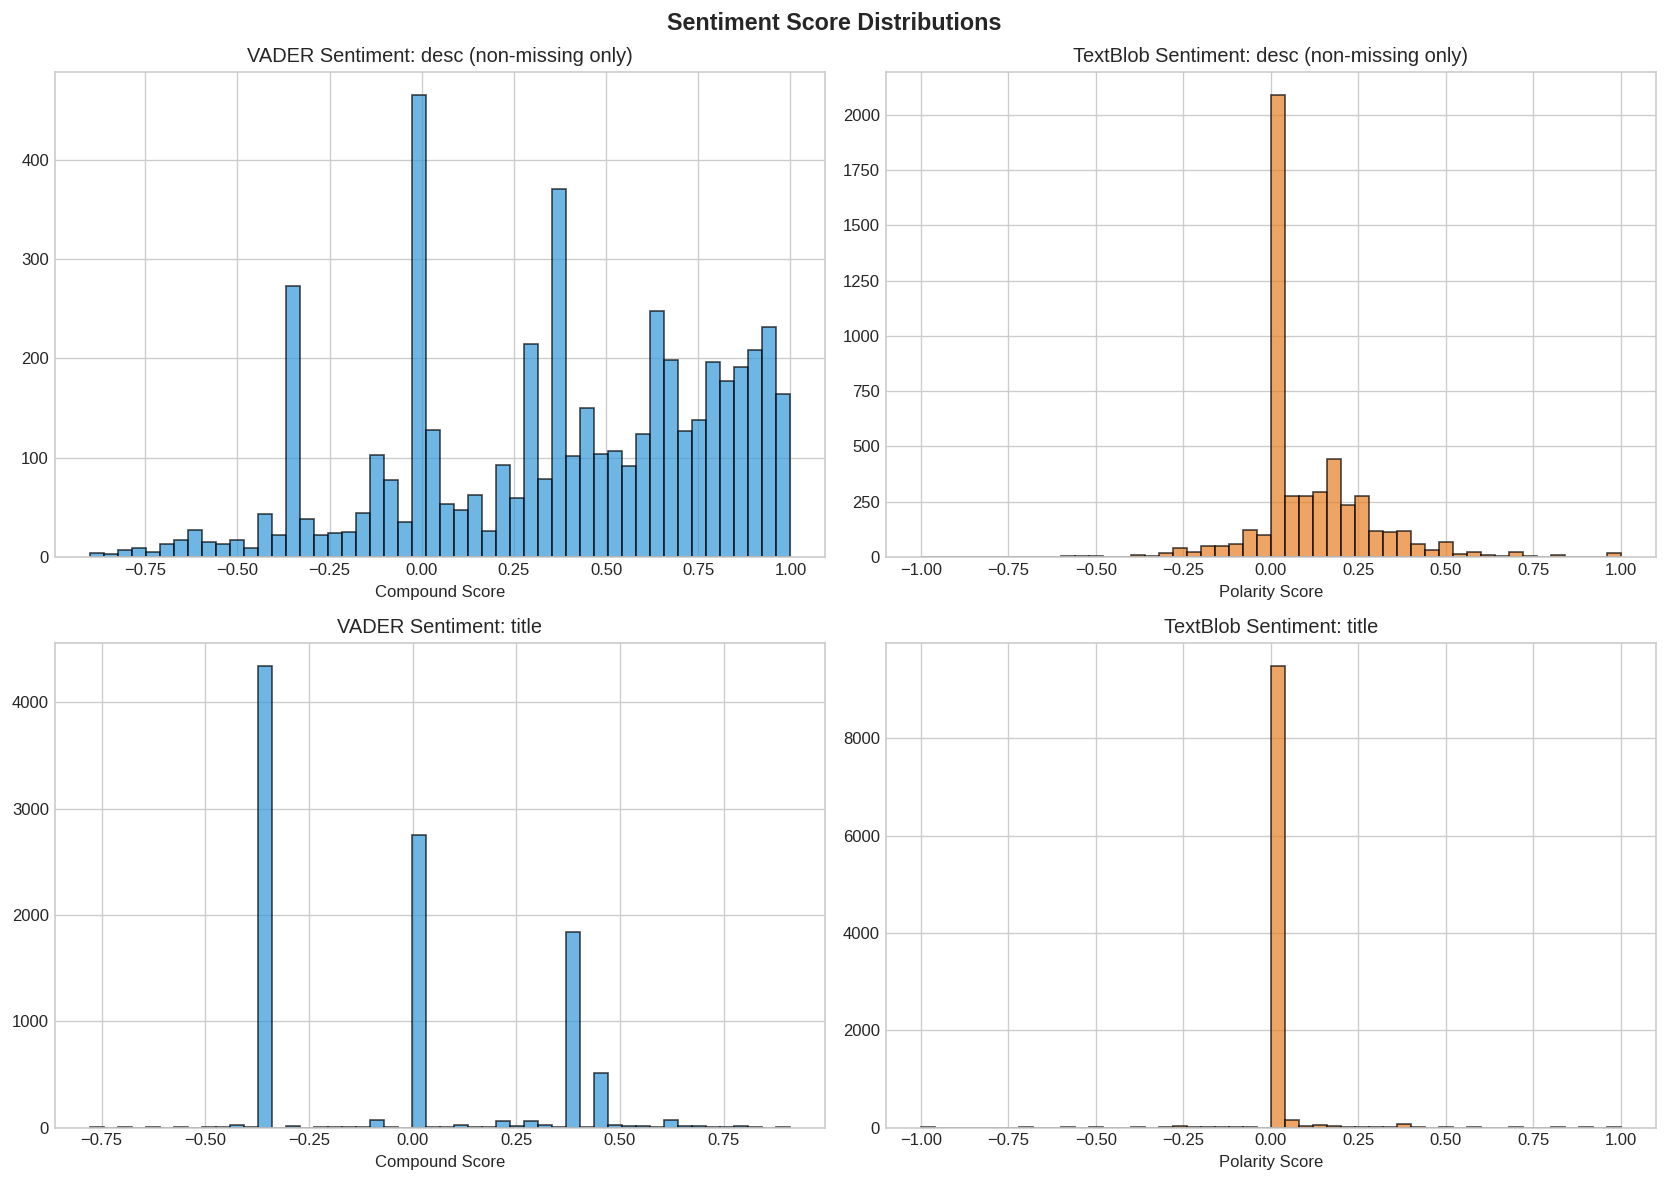

In [8]:
# Sentiment distribution: VADER vs TextBlob for desc and title
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# desc VADER
axes[0,0].hist(df_sample.loc[df_sample['desc_missing']==0, 'desc_vader'], bins=50, edgecolor='black', color='#3498db', alpha=0.7)
axes[0,0].set_title('VADER Sentiment: desc (non-missing only)')
axes[0,0].set_xlabel('Compound Score')

# desc TextBlob
axes[0,1].hist(df_sample.loc[df_sample['desc_missing']==0, 'desc_textblob'], bins=50, edgecolor='black', color='#e67e22', alpha=0.7)
axes[0,1].set_title('TextBlob Sentiment: desc (non-missing only)')
axes[0,1].set_xlabel('Polarity Score')

# title VADER
axes[1,0].hist(df_sample['title_vader'], bins=50, edgecolor='black', color='#3498db', alpha=0.7)
axes[1,0].set_title('VADER Sentiment: title')
axes[1,0].set_xlabel('Compound Score')

# title TextBlob
axes[1,1].hist(df_sample['title_textblob'], bins=50, edgecolor='black', color='#e67e22', alpha=0.7)
axes[1,1].set_title('TextBlob Sentiment: title')
axes[1,1].set_xlabel('Polarity Score')

plt.suptitle('Sentiment Score Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/sentiment_distributions.png', dpi=150)
plt.show()

VADER produces a broader distribution on `desc` with meaningful spread from -1 to +1. TextBlob concentrates heavily around 0 (neutral). For `title`, both methods show limited variation due to short, repetitive text. **VADER on `desc` is the most informative sentiment feature.**

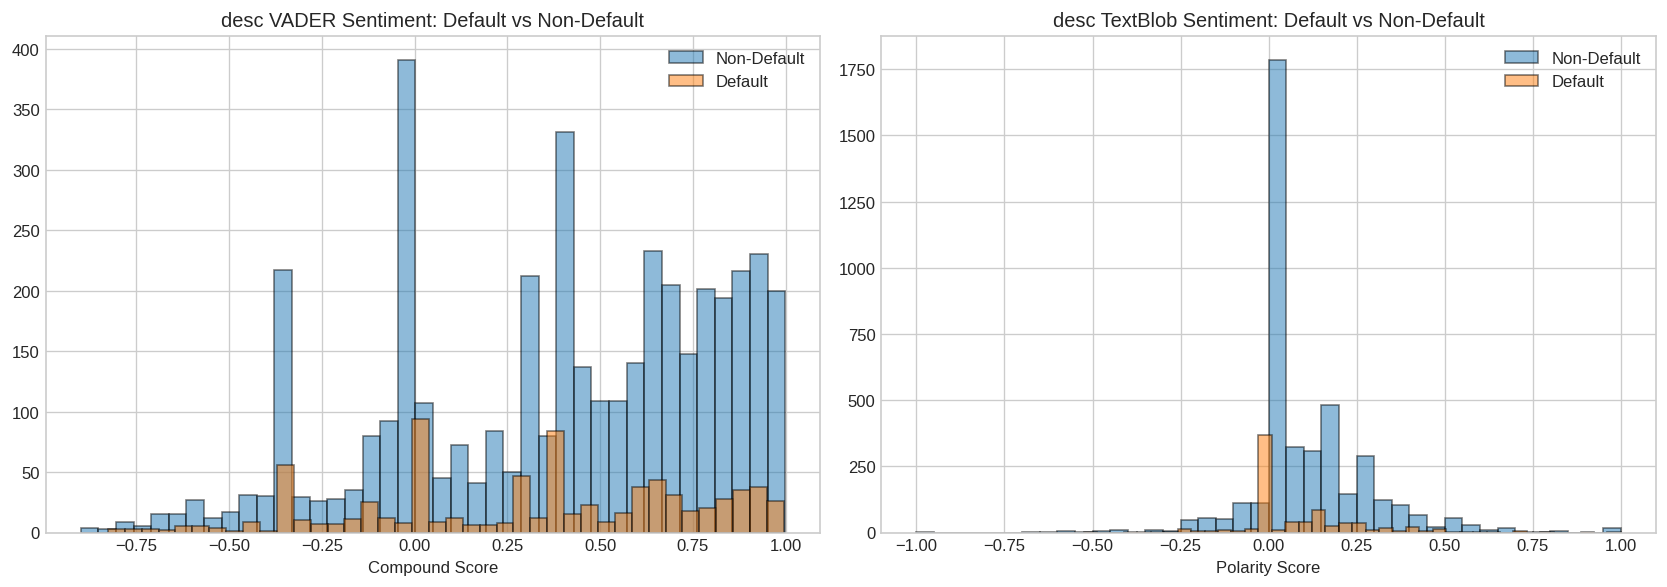

In [9]:
# Sentiment comparison: Default vs Non-default (desc, non-missing only)
df_has_desc = df_sample[df_sample['desc_missing'] == 0].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# VADER by default status
for label, group in df_has_desc.groupby('default_flag'):
    name = 'Default' if label == 1 else 'Non-Default'
    axes[0].hist(group['desc_vader'], bins=40, alpha=0.5, label=name, edgecolor='black')
axes[0].set_title('desc VADER Sentiment: Default vs Non-Default')
axes[0].set_xlabel('Compound Score')
axes[0].legend()

# TextBlob by default status
for label, group in df_has_desc.groupby('default_flag'):
    name = 'Default' if label == 1 else 'Non-Default'
    axes[1].hist(group['desc_textblob'], bins=40, alpha=0.5, label=name, edgecolor='black')
axes[1].set_title('desc TextBlob Sentiment: Default vs Non-Default')
axes[1].set_xlabel('Polarity Score')
axes[1].legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/sentiment_default_comparison.png', dpi=150)
plt.show()

Default vs Non-Default sentiment distributions largely overlap. Borrowers tend to use positive language regardless of eventual outcome — they are trying to get approved. Sentiment alone has limited discriminative power for predicting default.

/tmp/ipykernel_12497/1267212414.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_flag', y=col, data=data, ax=ax, palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_12497/1267212414.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(['Non-Default', 'Default'])
/tmp/ipykernel_12497/1267212414.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='default_flag', y=col, data=data, ax=ax, palette=['#2ecc71', '#e74c3c'])
/tmp/ipykernel_12497/1267212414.py:10: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocato

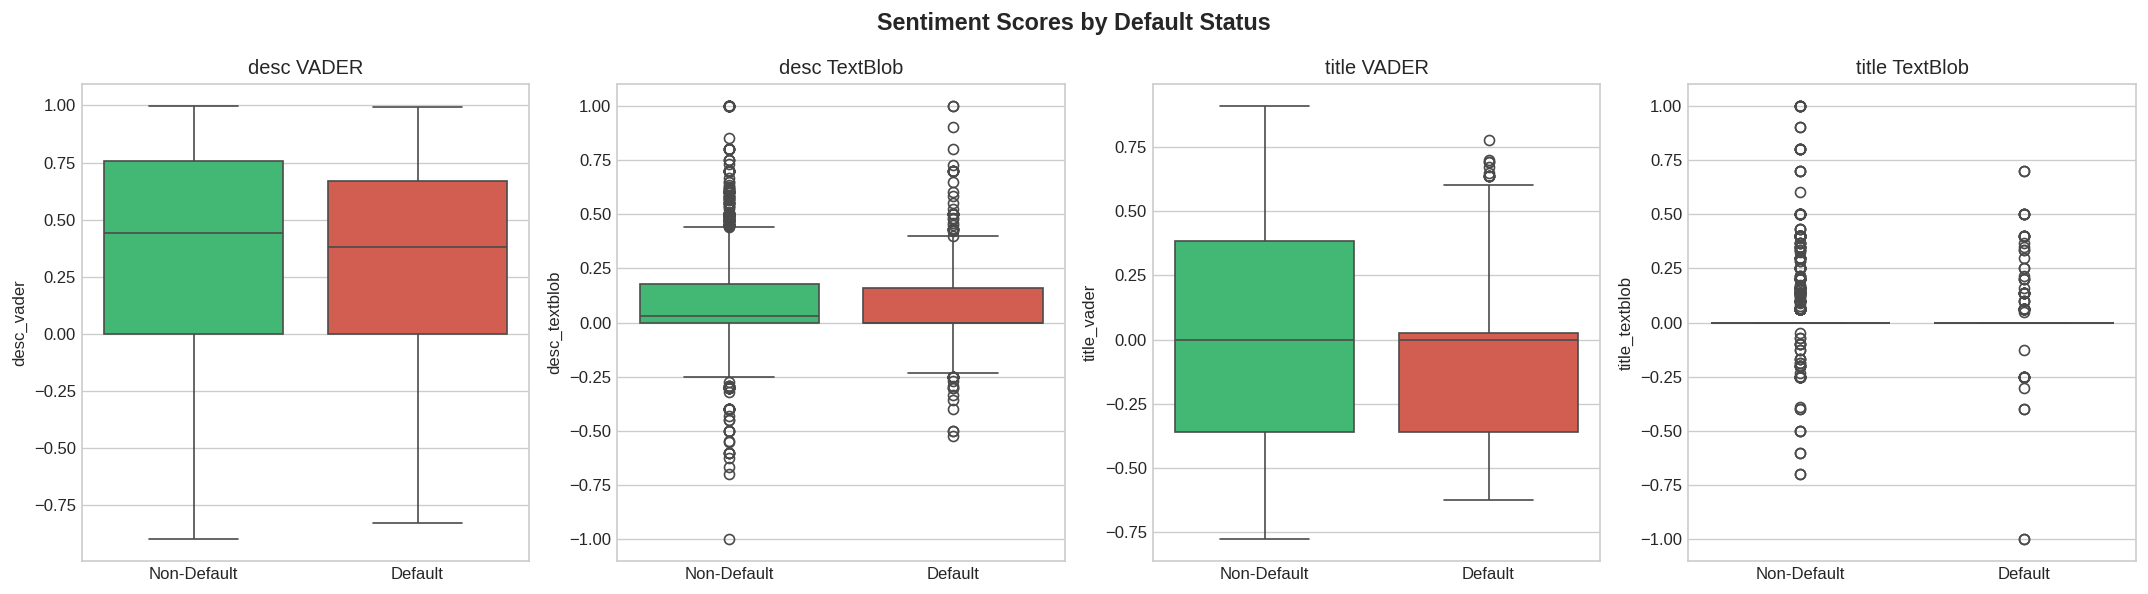

In [10]:
# Box plot: sentiment by default status
fig, axes = plt.subplots(1, 4, figsize=(18, 5))

sentiment_cols = ['desc_vader', 'desc_textblob', 'title_vader', 'title_textblob']
titles = ['desc VADER', 'desc TextBlob', 'title VADER', 'title TextBlob']

for ax, col, title in zip(axes, sentiment_cols, titles):
    data = df_sample if 'title' in col else df_has_desc
    sns.boxplot(x='default_flag', y=col, data=data, ax=ax, palette=['#2ecc71', '#e74c3c'])
    ax.set_xticklabels(['Non-Default', 'Default'])
    ax.set_title(title)
    ax.set_xlabel('')

plt.suptitle('Sentiment Scores by Default Status', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/sentiment_boxplots.png', dpi=150)
plt.show()

Box plots confirm: median sentiment is nearly identical between Default and Non-Default groups across all four measures. The slight difference in `desc_vader` is not practically significant.

## 4.6 TF-IDF Features

In [11]:
# TF-IDF on desc
cleaned_desc = df_sample['desc'].apply(clean_text)
tfidf_matrix, feature_names, vectorizer = build_tfidf_features(cleaned_desc, max_features=50)

# Add TF-IDF columns to dataframe
tfidf_df = pd.DataFrame(tfidf_matrix.toarray(), columns=[f'tfidf_{name}' for name in feature_names])
df_sample = pd.concat([df_sample.reset_index(drop=True), tfidf_df], axis=1)

print(f'Added {len(feature_names)} TF-IDF features')
print('Top 10 terms:', list(feature_names[:10]))

Added 50 TF-IDF features
Top 10 terms: ['bills', 'business', 'car', 'card', 'cards', 'club', 'company', 'consolidate', 'consolidation', 'credit']


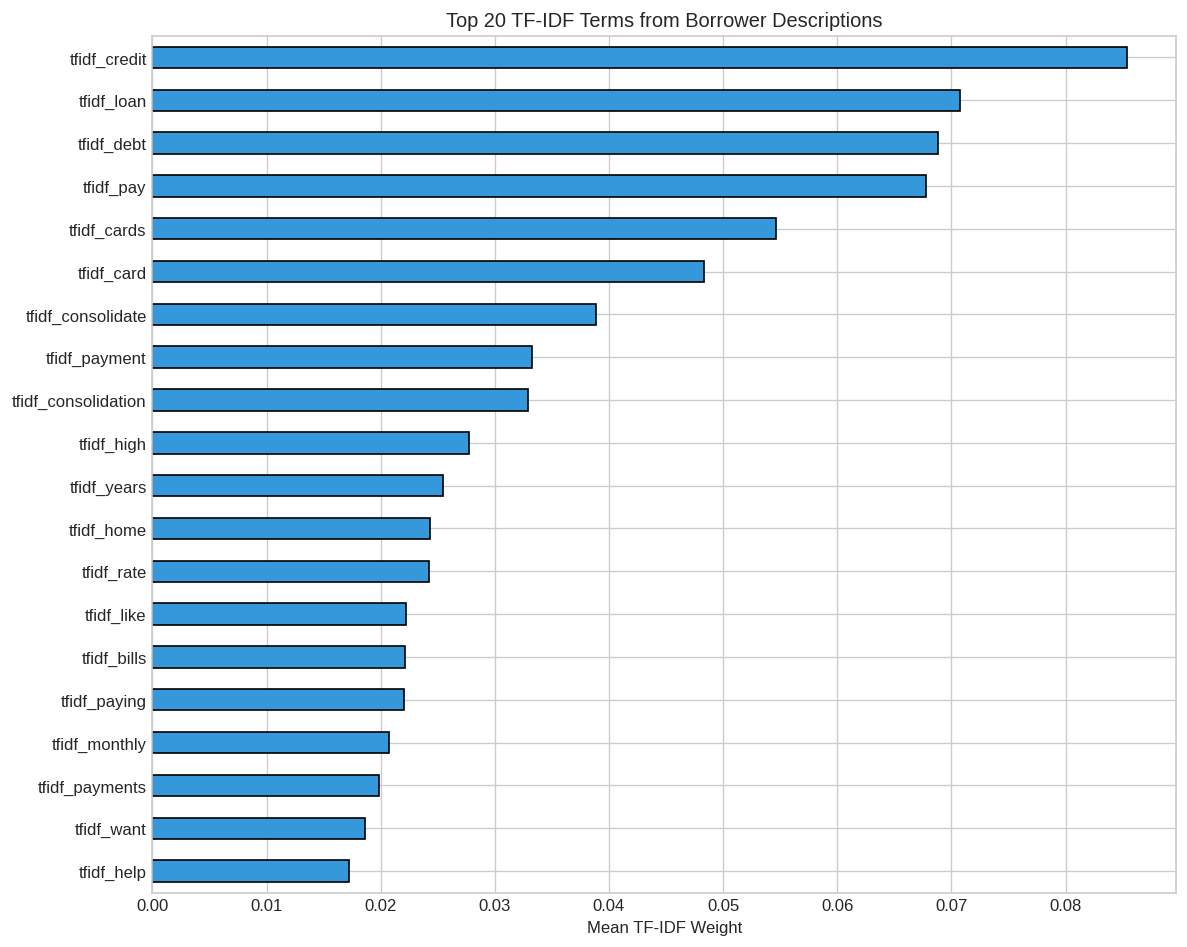

In [12]:
# Top 20 TF-IDF terms by average weight
tfidf_means = tfidf_df.mean().sort_values(ascending=True).tail(20)

fig, ax = plt.subplots(figsize=(10, 8))
tfidf_means.plot(kind='barh', ax=ax, color='#3498db', edgecolor='black')
ax.set_xlabel('Mean TF-IDF Weight')
ax.set_title('Top 20 TF-IDF Terms from Borrower Descriptions')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/tfidf_top_terms.png', dpi=150)
plt.show()

Top terms reflect borrowing purposes: credit/debt/loan dominate, followed by payment-related words and consolidation. These capture the topical content of borrower descriptions.

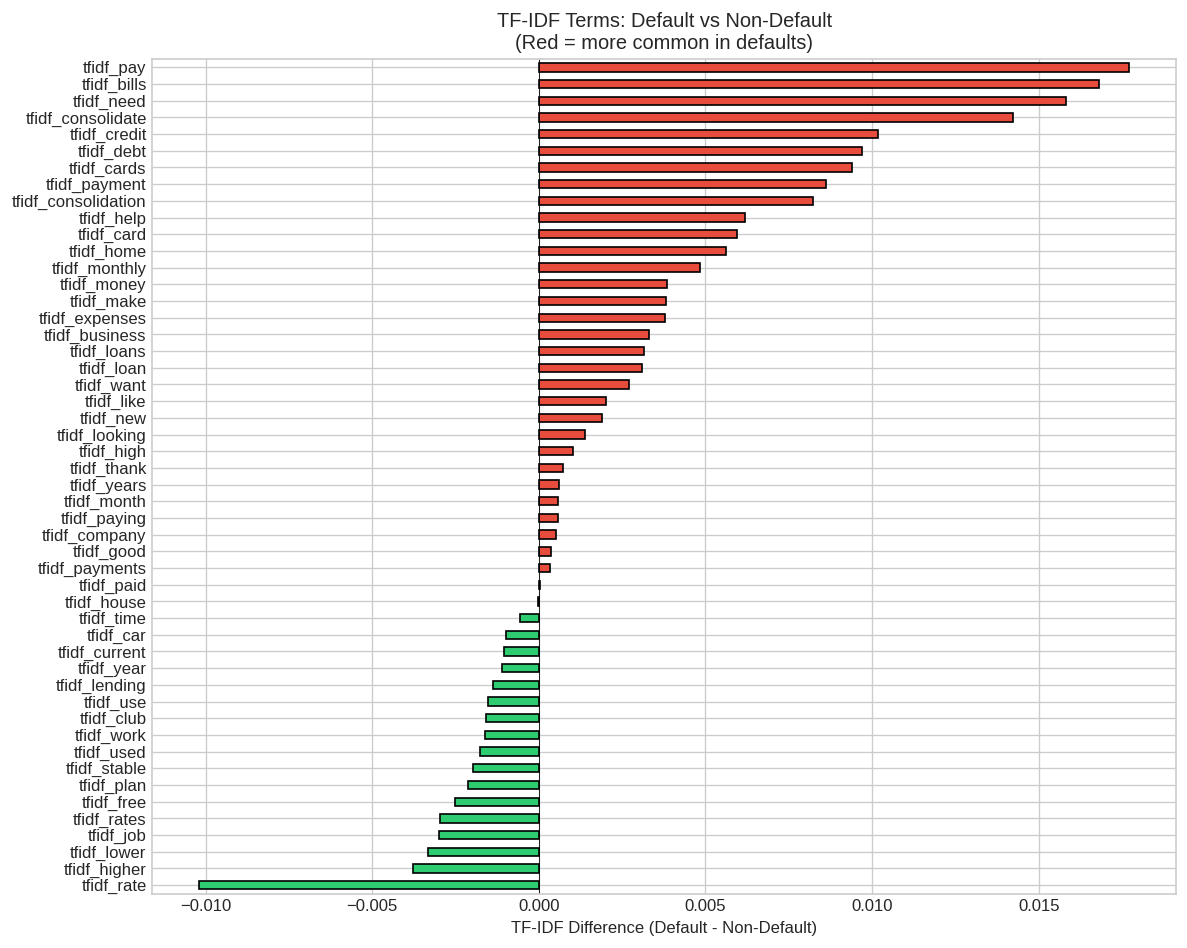

In [13]:
# TF-IDF term comparison: Default vs Non-Default
tfidf_cols = [c for c in df_sample.columns if c.startswith('tfidf_')]

default_means = df_sample[df_sample['default_flag'] == 1][tfidf_cols].mean()
nondefault_means = df_sample[df_sample['default_flag'] == 0][tfidf_cols].mean()

# Difference: which terms are more common in defaults?
diff = (default_means - nondefault_means).sort_values()

fig, ax = plt.subplots(figsize=(10, 8))
colors = ['#e74c3c' if v > 0 else '#2ecc71' for v in diff.values]
diff.plot(kind='barh', ax=ax, color=colors, edgecolor='black')
ax.set_xlabel('TF-IDF Difference (Default - Non-Default)')
ax.set_title('TF-IDF Terms: Default vs Non-Default\n(Red = more common in defaults)')
ax.axvline(x=0, color='black', linestyle='-', linewidth=0.5)
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/tfidf_default_comparison.png', dpi=150)
plt.show()

**Key finding:** Defaulters use more urgency-related words ("pay", "bills", "need", "help") suggesting financial distress. Non-defaulters use more optimization-related words ("rate", "lower", "plan", "stable") suggesting proactive financial management. This distinction — **reactive distress vs. proactive optimization** — is more informative than raw sentiment scores.

## 4.7 Occupation Clustering

In [14]:
df_sample['occupation_cluster'] = cluster_occupations(df_sample['emp_title'], n_clusters=20)
print(f'Unique clusters: {df_sample["occupation_cluster"].nunique()}')
print(f'\nCluster distribution:')
print(df_sample['occupation_cluster'].value_counts())

/opt/conda/lib/python3.11/site-packages/sklearn/cluster/_kmeans.py:1934: FutureWarning: The default value of `n_init` will change from 3 to 'auto' in 1.4. Set the value of `n_init` explicitly to suppress the warning
  super()._check_params_vs_input(X, default_n_init=3)


Unique clusters: 20

Cluster distribution:
occupation_cluster
12    4129
1     2448
7      749
2      696
9      221
15     199
17     169
13     165
8      154
10     151
4      142
19     136
6      119
5      102
11      81
3       81
18      77
0       73
16      70
14      38
Name: count, dtype: int64


In [15]:
# Show top job titles per cluster
print('Sample job titles per cluster:')
print('=' * 60)
for cluster_id in sorted(df_sample['occupation_cluster'].unique())[:10]:
    titles = df_sample[df_sample['occupation_cluster'] == cluster_id]['emp_title'].dropna().head(5).tolist()
    print(f'\nCluster {cluster_id}: {titles}')

Sample job titles per cluster:

Cluster 0: ['General Dynamics IT', 'GENERAL MANAGER', 'GENERAL MANAGER ', 'General Drafting & Design', 'General Palmer Hotel']

Cluster 1: ['Henrico COunty Public Schools', 'Zenith Insurance Company', 'Johnston Willis Hospital', 'LPL Financial', 'SOUTHEASTERN INTEGRATED MEDICAL, PL']

Cluster 2: []

Cluster 3: ['BUS OPERATOR', 'Process Operator', 'Crane Operator', 'machine operator', 'Operator 2']

Cluster 4: ['Systems Analyst', 'Storage Analyst', 'Program Analyst', 'Financial Analyst', 'Sr Systems Analyst']

Cluster 5: ['Lead X-ray tech', 'GE Inspection Tech.', 'Tetra Tech', 'Cert Pharmacy Tech', 'Test Tech 2']

Cluster 6: ['nurse', 'Registered Nurse', 'Night Charge Registered Nurse', 'Nurse Exchange', 'Nurse On Call']

Cluster 7: ['Startup Manager', 'Finance Manager', 'Manager', 'Store manager', 'Senior Account Manager']

Cluster 8: ['HR Specialist', 'Sales specialist', 'Parts Specialist', 'Area Specialist', 'Hydraulic System Specialist']

Cluster 9: [

Clustering groups 512K+ unique job titles into 20 occupation categories using TF-IDF + KMeans. Cluster 12 (largest) is a catch-all for unclassifiable entries; other clusters show clear themes: Analysts (4), Technicians (5), Nurses (6), Managers (7), Specialists (8), Directors (9).

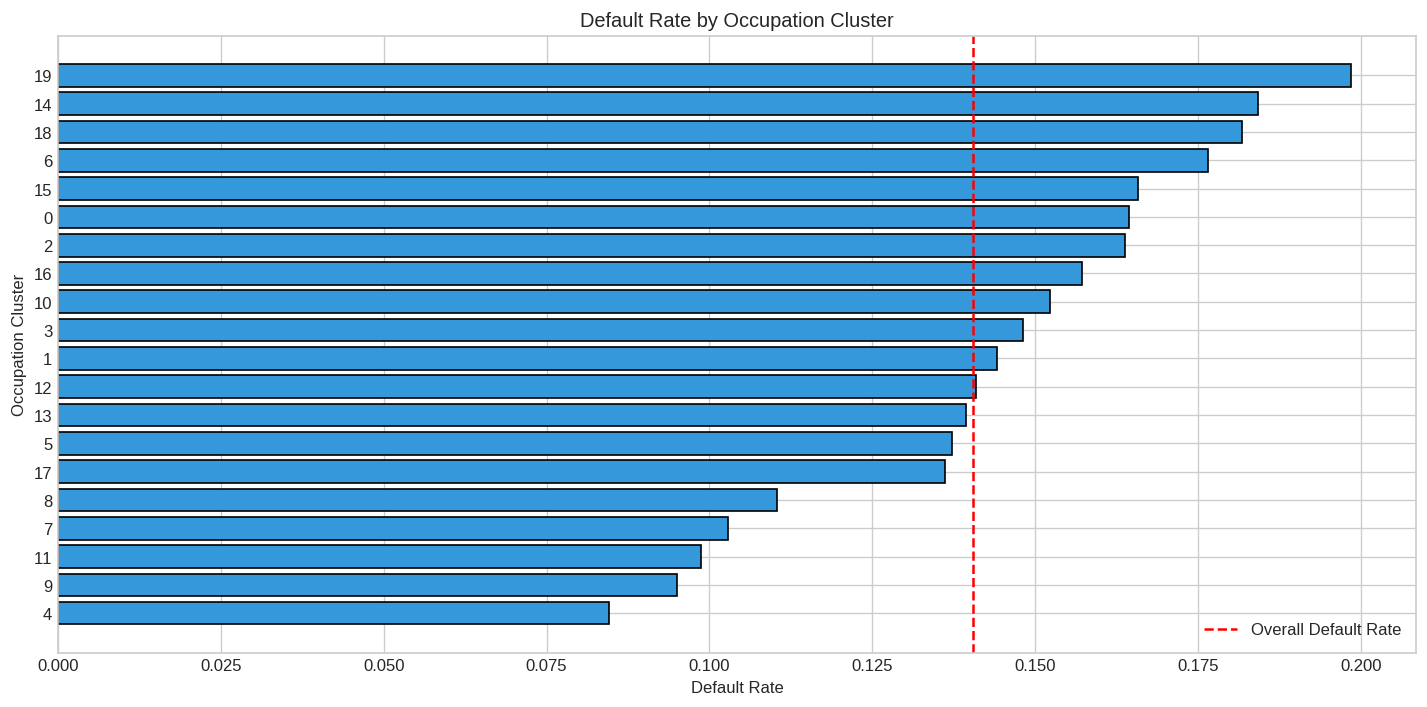

In [16]:
# Default rate by occupation cluster
cluster_default = df_sample.groupby('occupation_cluster').agg(
    count=('default_flag', 'count'),
    default_rate=('default_flag', 'mean')
).sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(12, 6))
bars = ax.barh(cluster_default.index.astype(str), cluster_default['default_rate'],
               color='#3498db', edgecolor='black')
ax.set_xlabel('Default Rate')
ax.set_ylabel('Occupation Cluster')
ax.set_title('Default Rate by Occupation Cluster')
ax.axvline(x=df_sample['default_flag'].mean(), color='red', linestyle='--', label='Overall Default Rate')
ax.legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/occupation_cluster_default_rate.png', dpi=150)
plt.show()

Default rates vary significantly by occupation: Analysts and Directors (~8–9%) have the lowest rates, while some clusters reach ~20%. Higher-seniority roles correlate with lower default risk, consistent with income and job stability expectations.

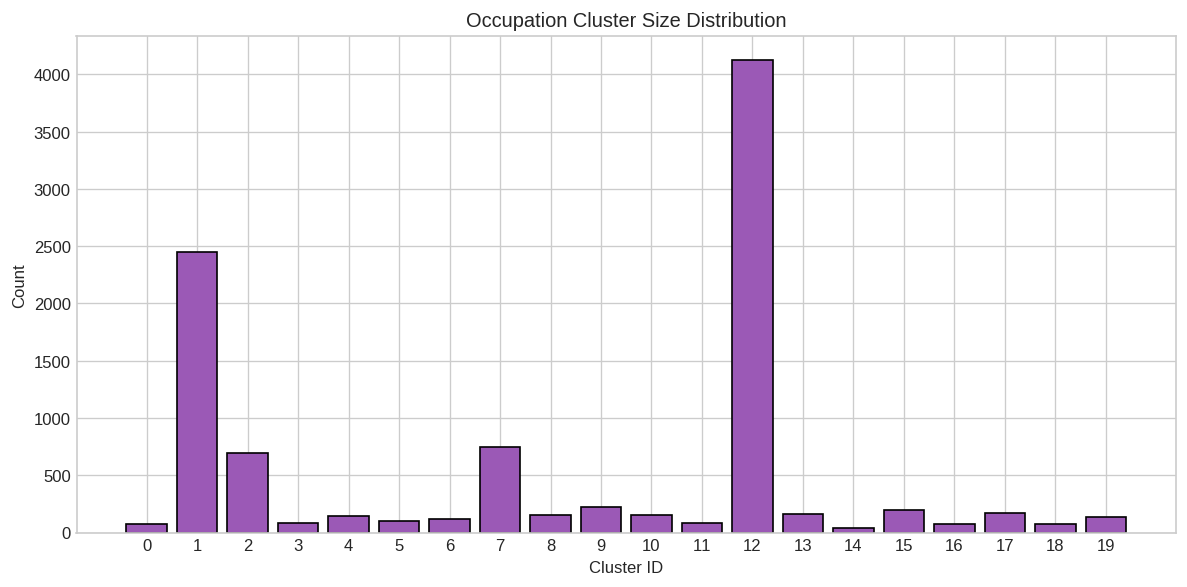

In [17]:
# Cluster size distribution
fig, ax = plt.subplots(figsize=(10, 5))
cluster_counts = df_sample['occupation_cluster'].value_counts().sort_index()
ax.bar(cluster_counts.index.astype(str), cluster_counts.values, color='#9b59b6', edgecolor='black')
ax.set_xlabel('Cluster ID')
ax.set_ylabel('Count')
ax.set_title('Occupation Cluster Size Distribution')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/occupation_cluster_sizes.png', dpi=150)
plt.show()

## 4.8 Title Analysis

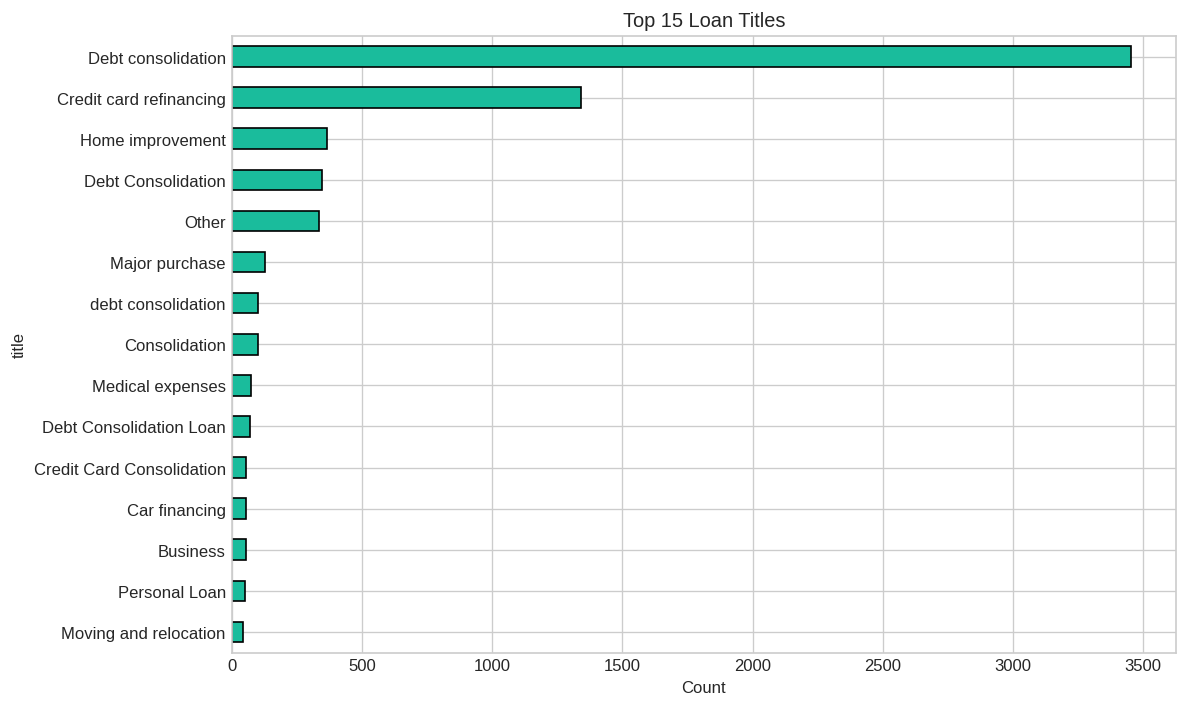

In [18]:
# Top 15 loan titles
title_counts = df_sample['title'].value_counts().head(15)

fig, ax = plt.subplots(figsize=(10, 6))
title_counts.sort_values().plot(kind='barh', ax=ax, color='#1abc9c', edgecolor='black')
ax.set_xlabel('Count')
ax.set_title('Top 15 Loan Titles')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/top_loan_titles.png', dpi=150)
plt.show()

"Debt consolidation" dominates (~35%), with many spelling variants. Titles like "Medical expenses", "Business", and "Car financing" each represent distinct borrowing purposes with different risk profiles.

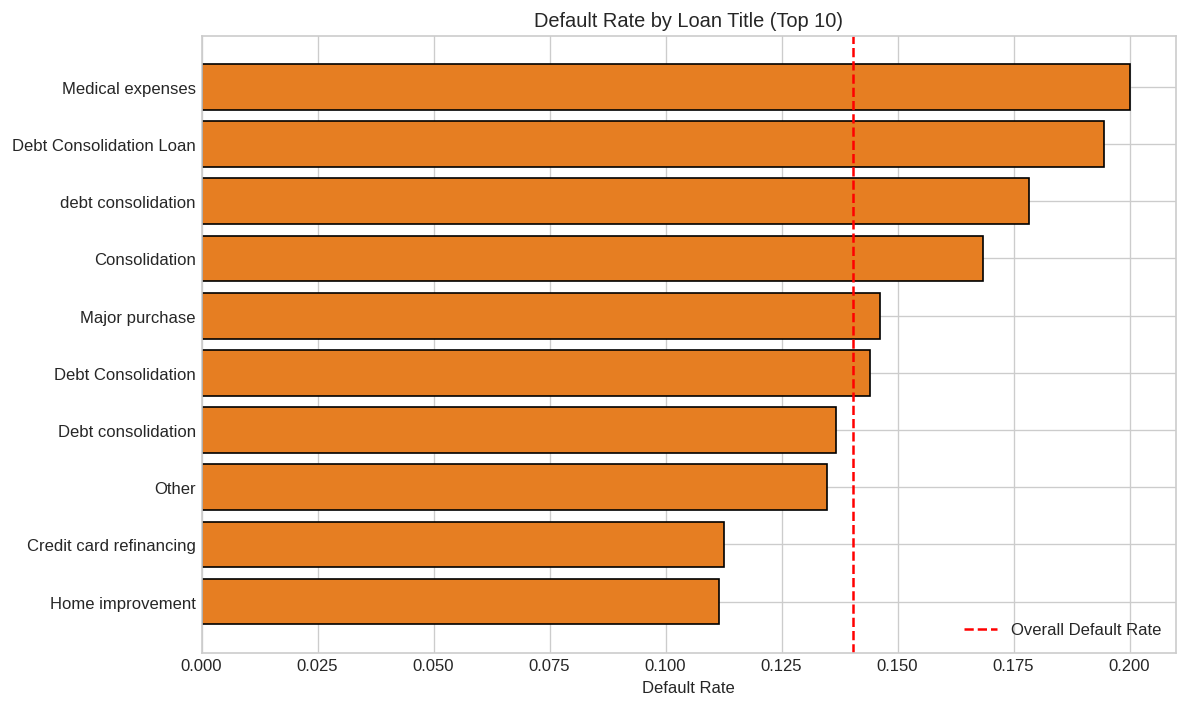

In [19]:
# Default rate by top loan titles
top_titles = df_sample['title'].value_counts().head(10).index
title_default = df_sample[df_sample['title'].isin(top_titles)].groupby('title')['default_flag'].agg(['mean', 'count'])
title_default.columns = ['default_rate', 'count']
title_default = title_default.sort_values('default_rate', ascending=True)

fig, ax = plt.subplots(figsize=(10, 6))
bars = ax.barh(title_default.index, title_default['default_rate'], color='#e67e22', edgecolor='black')
ax.set_xlabel('Default Rate')
ax.set_title('Default Rate by Loan Title (Top 10)')
ax.axvline(x=df_sample['default_flag'].mean(), color='red', linestyle='--', label='Overall Default Rate')
ax.legend()

plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/title_default_rate.png', dpi=150)
plt.show()

"Medical expenses" has the highest default rate (~20%), while "Home improvement" and "Credit card refinancing" have the lowest (~10–11%). Borrowing purpose is a strong predictor: **emergency/distress borrowing defaults more than proactive/optimization borrowing.**

## 4.9 NLP Feature Correlation Heatmap

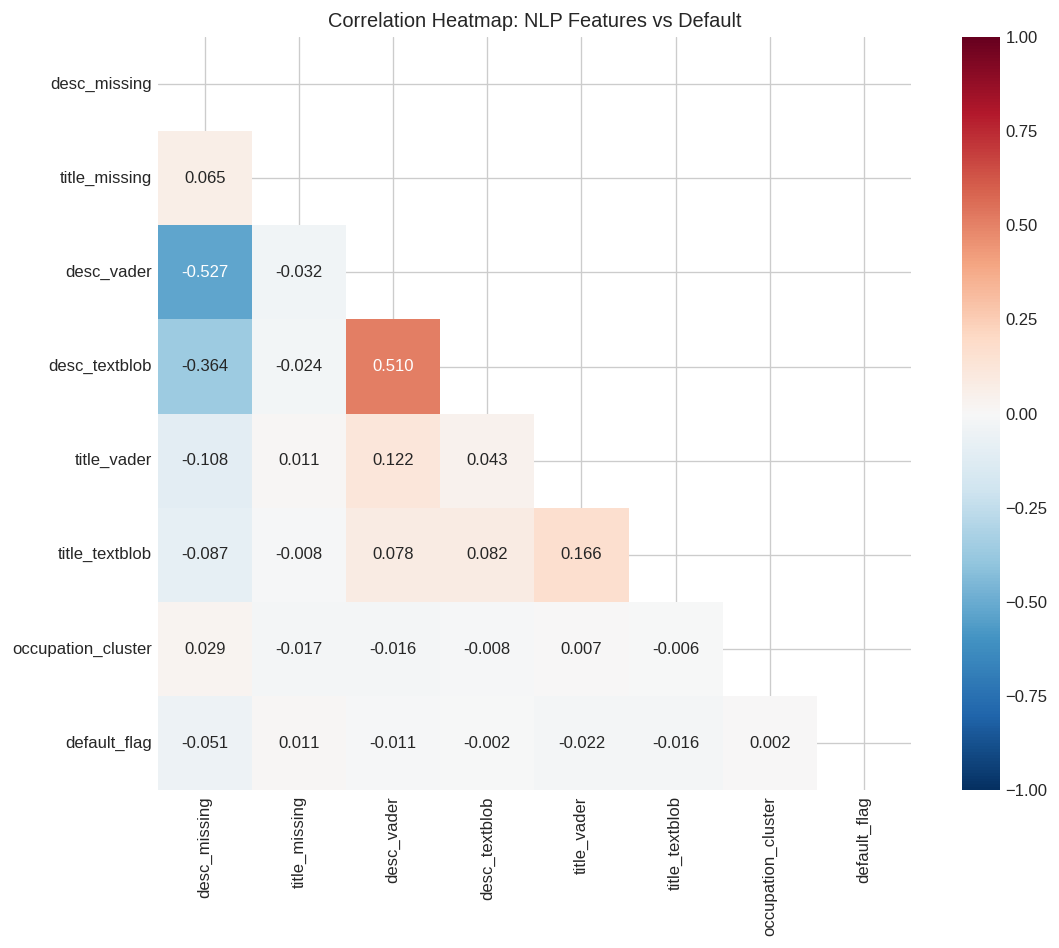

In [20]:
# Correlation heatmap of NLP features (non-TF-IDF)
nlp_features = ['desc_missing', 'title_missing', 'desc_vader', 'desc_textblob',
                'title_vader', 'title_textblob', 'occupation_cluster', 'default_flag']

corr = df_sample[nlp_features].corr()

fig, ax = plt.subplots(figsize=(10, 8))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.3f', cmap='RdBu_r', center=0,
            square=True, ax=ax, vmin=-1, vmax=1)
ax.set_title('Correlation Heatmap: NLP Features vs Default')
plt.tight_layout()
plt.savefig('/home/jovyan/work/outputs/figures/nlp_correlation_heatmap.png', dpi=150)
plt.show()

Individual NLP features show weak linear correlation with default (all < 0.05). However, `desc_vader` and `desc_textblob` are correlated (0.51) — redundant, so we may drop TextBlob. `occupation_cluster` is uncorrelated with other NLP features, providing independent information. Note: low linear correlation does not mean no predictive power — occupation clusters showed 8–20% default rate variation in the bar chart above.

## 4.10 NLP Feature Summary

In [21]:
# Summary of all NLP features created
nlp_cols = (['desc_missing', 'title_missing', 'desc_vader', 'desc_textblob',
             'title_vader', 'title_textblob', 'occupation_cluster'] +
            [c for c in df_sample.columns if c.startswith('tfidf_')])

print(f'Total NLP features created: {len(nlp_cols)}')
print(f'\nFeature breakdown:')
print(f'  Missing flags:        2  (desc_missing, title_missing)')
print(f'  Sentiment scores:     4  (desc/title x VADER/TextBlob)')
print(f'  Occupation cluster:   1')
print(f'  TF-IDF features:      {len([c for c in nlp_cols if c.startswith("tfidf_")])}')
print(f'  -------------------------')
print(f'  Total:                {len(nlp_cols)}')

print(f'\nSample data with NLP features:')
df_sample[nlp_cols].describe()

Total NLP features created: 57

Feature breakdown:
  Missing flags:        2  (desc_missing, title_missing)
  Sentiment scores:     4  (desc/title x VADER/TextBlob)
  Occupation cluster:   1
  TF-IDF features:      50
  -------------------------
  Total:                57

Sample data with NLP features:


,desc_missing,title_missing,desc_vader,desc_textblob,title_vader,title_textblob,occupation_cluster,tfidf_bills,tfidf_business,tfidf_car,...,tfidf_rates,tfidf_stable,tfidf_thank,tfidf_time,tfidf_use,tfidf_used,tfidf_want,tfidf_work,tfidf_year,tfidf_years
count,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,...,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000
mean,0.500000,0.004600,0.188242,0.048376,-0.050412,0.007815,7.991300,0.022086,0.008969,0.010959,...,0.011420,0.009300,0.014407,0.017186,0.010855,0.013409,0.018640,0.009892,0.010193,0.025495
std,0.500025,0.067671,0.357440,0.132952,0.319529,0.067470,5.304096,0.103056,0.075550,0.077767,...,0.069608,0.057489,0.078199,0.079379,0.065707,0.079122,0.090706,0.066987,0.065262,0.096383
min,0.000000,0.000000,-0.900100,-1.000000,-0.778300,-1.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,0.000000,0.000000,0.000000,0.000000,-0.361200,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,0.500000,0.000000,0.000000,0.000000,0.000000,0.000000,11.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,1.000000,0.000000,0.401900,0.017500,0.381800,0.000000,12.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,1.000000,1.000000,0.998900,1.000000,0.910000,1.000000,19.000000,1.000000,1.000000,1.000000,...,0.870073,0.746848,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.877237,1.000000


## 4.11 Save Hybrid Feature Matrix

After Weiyu completes notebooks 01-03, merge NLP features with baseline features and save.

In [ ]:
# TODO: After Weiyu's baseline features are ready
# 1. Load features_baseline.parquet
# 2. Run NLP pipeline on full data (not sample)
# 3. Merge NLP features with baseline features
# 4. Save as features_hybrid.parquet

# For now, save sample results
df_sample.to_csv('/home/jovyan/work/outputs/tables/nlp_features_sample.csv', index=False)
print(f'Sample NLP features saved. Shape: {df_sample.shape}')